# Дополнительное задание 4
# Выполнил: Ибраев Дамир Беркутбаевич
# Вариант 2.1

### Задание 1

На данном этапе были импортированы необходимые библиотеки и загружен набор данных из файла CSV. Для контроля корректности импорта выведены первые строки таблицы. По ним видно, что набор содержит два числовых признака: вес и рост.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('вариант2_1.csv')

df.head()

,Weight,Height
0,126.7983,69.00102
1,131.9365,67.75162
2,135.9003,67.08500
3,151.5006,69.01390
4,143.9136,66.13638


На данном этапе были импортированы необходимые библиотеки и загружен набор данных из файла CSV. Для контроля корректности импорта выведены первые строки таблицы. По ним видно, что набор содержит два числовых признака: вес и рост.

In [4]:
print("Размер набора данных:", df.shape)
print()
print(df.info())
print()
print(df.describe())

Размер набора данных: (1000, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  1000 non-null   float64
 1   Height  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB
None

            Weight       Height
count  1000.000000  1000.000000
mean    127.295283    67.911255
std      11.269657     1.889475
min      95.887910    62.449640
25%     119.833950    66.706565
50%     127.133500    67.946710
75%     134.830850    69.164192
max     168.881000    74.283760


Диаграмма рассеяния показывает наличие положительной зависимости между весом и ростом: с увеличением веса, как правило, увеличивается и рост. Точки располагаются достаточно компактно вдоль возрастающего направления, поэтому можно предположить, что линейная модель будет описывать данные достаточно адекватно.

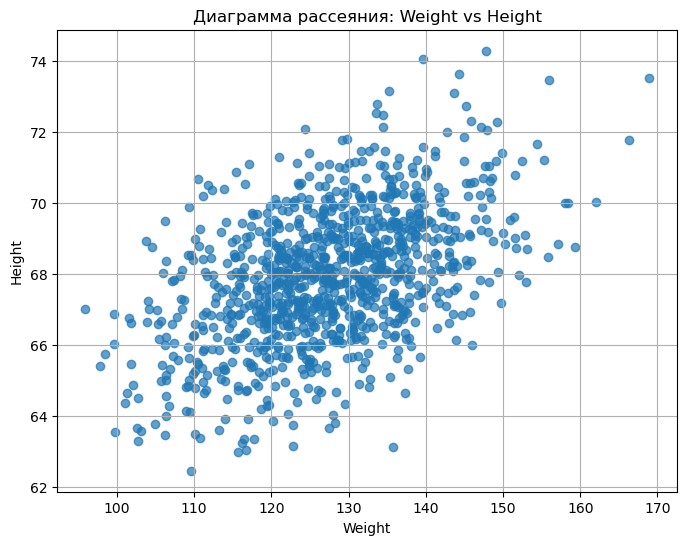

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Weight'], df['Height'], alpha=0.7)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Диаграмма рассеяния: Weight vs Height')
plt.grid(True)
plt.show()

Гистограммы показывают, что распределения обоих признаков близки к нормальным: значения сосредоточены около центральной части диапазона, а по краям количество наблюдений уменьшается. Явно выраженных выбросов не наблюдается. Такой характер распределения является благоприятным для построения линейной модели.

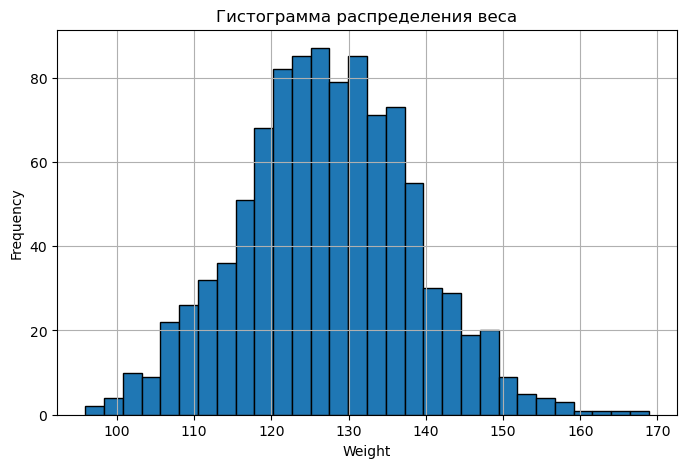

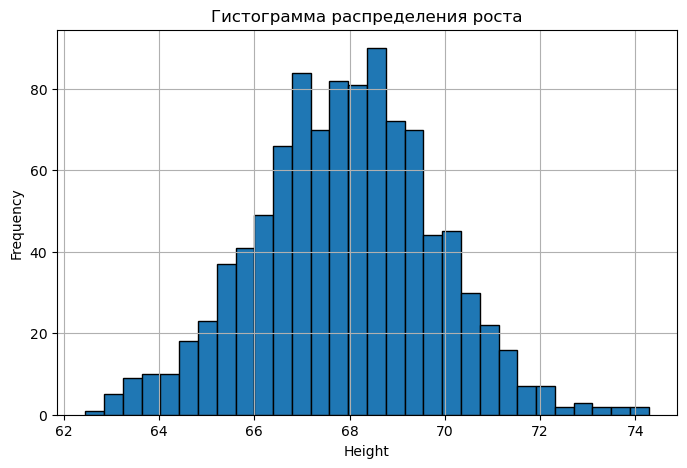

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df['Weight'], bins=30, edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Гистограмма распределения веса')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['Height'], bins=30, edgecolor='black')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Гистограмма распределения роста')
plt.grid(True)
plt.show()

Рассчитанный коэффициент корреляции позволяет оценить степень линейной взаимосвязи между весом и ростом. Положительное значение, близкое к 1, указывает на заметную прямую зависимость. Следовательно, использование линейной регрессии для прогнозирования роста по весу является обоснованным.

In [7]:
corr = df['Weight'].corr(df['Height'])
print("Коэффициент корреляции между Weight и Height:", corr)

Коэффициент корреляции между Weight и Height: 0.4886298067895269


Данные были разделены на обучающую и тестовую выборки в соотношении 90/10. Обучающая выборка используется для построения модели, а тестовая — для проверки её обобщающей способности на новых данных, которые не участвовали в обучении.

In [11]:
X = df[['Weight']]
y = df['Height']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("Обучающая выборка:", X_train.shape, y_train.shape)
print("Тестовая выборка:", X_test.shape, y_test.shape)

Обучающая выборка: (900, 1) (900,)
Тестовая выборка: (100, 1) (100,)


В результате обучения модели было получено уравнение линейной регрессии:

**Height = k · Weight + b**

Для данного набора данных:
**Height = ... · Weight + ...**

Это уравнение показывает, как изменяется прогнозируемый рост при изменении веса на одну единицу.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

k = model.coef_[0]
b = model.intercept_

print("Коэффициент наклона:", k)
print("Свободный член:", b)

Коэффициент наклона: 0.08197124670529818
Свободный член: 57.48660339898064


In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

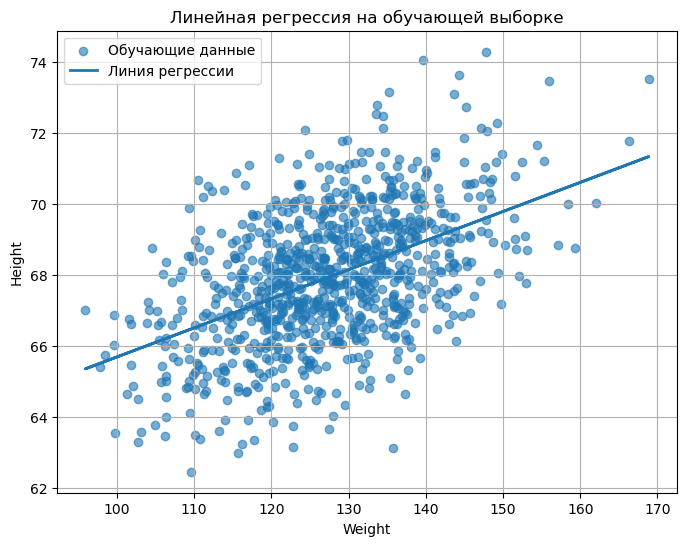

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, alpha=0.6, label='Обучающие данные')
plt.plot(X_train, y_train_pred, linewidth=2, label='Линия регрессии')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Линейная регрессия на обучающей выборке')
plt.legend()
plt.grid(True)
plt.show()

На графике видно, что линия регрессии проходит через центральную область облака точек и отражает общий тренд зависимости роста от веса. Значительная часть наблюдений расположена близко к линии, что свидетельствует о приемлемой обобщающей способности модели. При этом отдельные отклонения точек от линии показывают, что реальная зависимость не является абсолютно точной, и в данных присутствует естественный разброс.

In [15]:
results = pd.DataFrame({
    'Weight': X_test['Weight'].values,
    'True_Height': y_test.values,
    'Predicted_Height': y_test_pred
})

results['Error'] = results['True_Height'] - results['Predicted_Height']
results['Abs_Error'] = np.abs(results['Error'])

results.head(10)

,Weight,True_Height,Predicted_Height,Error,Abs_Error
0,124.9258,70.75201,67.726927,3.025083,3.025083
1,130.2530,67.33368,68.163604,-0.829924,0.829924
2,133.0454,67.59318,68.392501,-0.799321,0.799321
3,155.8502,68.48414,70.261839,-1.777699,1.777699
4,106.7157,64.26905,66.234222,-1.965172,1.965172
5,138.9571,67.39155,68.877090,-1.485540,1.485540
6,142.7132,71.98935,69.184982,2.804368,2.804368
7,138.5499,68.76140,68.843711,-0.082311,0.082311
8,116.4184,63.33461,67.029565,-3.694955,3.694955
9,125.1019,66.65382,67.741362,-1.087542,1.087542


Для нескольких объектов тестовой выборки были выведены истинные значения роста, прогнозы модели и ошибки предсказания. Ошибка показывает, насколько прогноз модели отличается от фактического значения. Наличие как положительных, так и отрицательных ошибок означает, что модель в одних случаях немного завышает прогноз, а в других — занижает его.

In [16]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print("MSE на обучающей выборке:", mse_train)
print("MSE на тестовой выборке:", mse_test)

MSE на обучающей выборке: 2.711413636402643
MSE на тестовой выборке: 2.748262975624109


Среднеквадратичная ошибка на обучающей выборке характеризует качество подгонки модели под известные данные, а на тестовой — качество работы модели на новых объектах. Если значения ошибок на обучающей и тестовой выборках близки друг к другу, это говорит о том, что модель не переобучена и обладает нормальной способностью к обобщению. Если ошибка на тестовой выборке значительно больше, чем на обучающей, это может указывать на ухудшение качества прогнозирования на новых данных.

### Вывод

В ходе выполнения работы был проведён первичный анализ набора данных, содержащего значения веса и роста подростков. Анализ показал наличие положительной корреляции между признаками и отсутствие серьёзных проблем в распределениях данных.

На основе обучающей выборки была построена модель линейной регрессии для прогнозирования роста по весу. Визуальный анализ и расчёт среднеквадратичной ошибки показали, что модель в целом адекватно описывает зависимость и может использоваться для приближённого прогнозирования роста по значению веса.

## Задание 2

Импортируем набор данных о продаже недвижимости в Нью-Йорке. Для корректного чтения файла использован разделитель `;`, так как данные в CSV-файле разделены именно точкой с запятой. После загрузки были выведены первые строки таблицы для контроля корректности импорта и общего ознакомления со структурой набора данных.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('NY-House-Dataset_2_1.csv', sep=';', engine='python')

df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Century Homes Realty Group LLC,House for sale,1790000,4,2.0,NaN,69-55 Kessel St,"Forest Hills, NY 11375","69-55 Kessel StForest Hills, NY 11375",United States,New York,Queens County,Queens,Kessel Street,"69-55 Kessel St, Flushing, NY 11375, USA",40.714321,-73.851440
1,Brokered by Best American Homes Inc,Multi-family home for sale,1175000,9,3.0,NaN,32-27 92nd St,"East Elmhurst, NY 11369","32-27 92nd StEast Elmhurst, NY 11369",United States,New York,Queens County,Queens,92nd Street,"32-27 92nd St, Flushing, NY 11369, USA",40.757913,-73.876076
2,Brokered by Douglas Elliman - Garden City,House for sale,579000,4,2.0,NaN,1523 Bayview Ave,"Bronx, NY 10465","1523 Bayview AveBronx, NY 10465",United States,New York,Bronx County,The Bronx,Bayview Avenue,"1523 Bayview Ave, Bronx, NY 10465, USA",40.845450,-73.817760
3,"Brokered by Robert E. Hill, Inc.",Co-op for sale,249000,1,1.0,850.0,601 Kappock St Apt 3N,"Bronx, NY 10463","601 Kappock St Apt 3NBronx, NY 10463",New York,Bronx County,The Bronx,Spuyten Duyvil,601,"601 Kappock St #3n, Bronx, NY 10463, USA",40.878977,-73.916004
4,Brokered by United Realty Associates,House for sale,2480000,3,2.0,3600.0,151-06 25th Ave,"Whitestone, NY 11357","151-06 25th AveWhitestone, NY 11357",United States,New York,Queens County,Queens,25th Avenue,"15106 25th Ave, Whitestone, NY 11357, USA",40.775458,-73.812549


Набор данных содержит как количественные, так и категориальные признаки. Целевым признаком является стоимость недвижимости `PRICE`. Также в таблице присутствуют текстовые поля, адресные характеристики и географические координаты. Часть признаков содержит пропущенные значения, поэтому на этапе предварительной обработки потребуется выполнить их заполнение.

In [19]:
print("Размер набора данных:", df.shape)
print()
print(df.info())
print()
display(df.describe(include='all'))

Размер набора данных: (500, 17)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  500 non-null    object 
 1   TYPE                         500 non-null    object 
 2   PRICE                        500 non-null    int64  
 3   BEDS                         500 non-null    int64  
 4   BATH                         474 non-null    float64
 5   PROPERTYSQFT                 340 non-null    float64
 6   ADDRESS                      500 non-null    object 
 7   STATE                        500 non-null    object 
 8   MAIN_ADDRESS                 500 non-null    object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  500 non-null    object 
 10  LOCALITY                     471 non-null    object 
 11  SUBLOCALITY                  500 non-null    object 
 12  STREET_NAME                  500 non-null    

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
count,500,500,5.000000e+02,500.000000,474.000000,340.000000,500,500,500,500,471,500,500,500,500,486.000000,486.000000
unique,258,10,NaN,NaN,NaN,NaN,479,163,479,7,9,13,63,442,479,NaN,NaN
top,Brokered by COMPASS,House for sale,NaN,NaN,NaN,NaN,2417 Cambreleng Ave,"Bronx, NY 10463","2417 Cambreleng AveBronx, NY 10458",United States,New York,Queens County,Queens,40,"2417 Cambreleng Ave, Bronx, NY 10458, USA",NaN,NaN
freq,45,159,NaN,NaN,NaN,NaN,2,22,2,329,312,92,92,3,2,NaN,NaN
mean,NaN,NaN,1.764118e+06,3.638000,2.641350,2491.179412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.714511,-73.939323
std,NaN,NaN,4.251412e+06,3.114218,2.879184,3489.366772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100475,0.117345
min,NaN,NaN,6.000000e+04,1.000000,1.000000,440.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.502294,-74.250510
25%,NaN,NaN,4.999000e+05,2.000000,1.000000,1064.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.623816,-73.993693
50%,NaN,NaN,7.895000e+05,3.000000,2.000000,1600.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.727705,-73.925626
75%,NaN,NaN,1.288250e+06,4.000000,3.000000,2418.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.782613,-73.856567


Целевой признак `PRICE` был сохранён отдельно, так как именно его требуется прогнозировать. Далее из набора входных признаков были удалены поля, явно указанные в условии задания: адресные строки и координаты. Такое исключение позволяет убрать признаки, которые либо избыточны, либо неудобны для прямого использования в базовой линейной модели без отдельной специализированной обработки.

In [20]:
y = df['PRICE']
X = df.drop(columns=['PRICE'])

X = X.drop(columns=[
    'ADDRESS',
    'STATE',
    'MAIN_ADDRESS',
    'FORMATTED_ADDRESS',
    'LATITUDE',
    'LONGITUDE'
])

print("Размер X после удаления столбцов:", X.shape)
print("Признаки:")
print(X.columns.tolist())

Размер X после удаления столбцов: (500, 10)
Признаки:
['BROKERTITLE', 'TYPE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME']


Данные были разделены на обучающую и тестовую выборки в соотношении 80/20. Обучающая выборка используется для построения всех этапов предварительной обработки и обучения модели, а тестовая — для проверки качества работы модели на новых данных. Такой подход позволяет корректно оценить обобщающую способность модели.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Обучающая выборка:", X_train.shape, y_train.shape)
print("Тестовая выборка:", X_test.shape, y_test.shape)

Обучающая выборка: (400, 10) (400,)
Тестовая выборка: (100, 10) (100,)


Для дальнейшей обработки признаки были разделены на две группы: количественные и категориальные. Для количественных признаков будут использоваться заполнение пропусков и масштабирование, а для категориальных — заполнение пропусков и кодирование методом one-hot encoding. Такое разделение необходимо, поскольку разные типы признаков требуют разных процедур подготовки.

In [23]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", numeric_features)
print()
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['BEDS', 'BATH', 'PROPERTYSQFT']

Категориальные признаки: ['BROKERTITLE', 'TYPE', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME']


На обучающей выборке была построена схема предварительной обработки данных. Для количественных признаков пропущенные значения заменяются медианой, после чего признаки масштабируются. Для категориальных признаков пропуски заменяются наиболее частым значением, а затем выполняется one-hot кодирование. Важно, что все параметры этой обработки вычисляются только по обучающей выборке, что исключает утечку информации из тестовых данных.

In [24]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [27]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
regressor = model.named_steps['regressor']

print("Количество коэффициентов:", len(regressor.coef_))
print("Свободный член:", regressor.intercept_)
print("Первые 20 коэффициентов:")
print(regressor.coef_[:20])

Количество коэффициентов: 684
Свободный член: 1885114.7271797047
Первые 20 коэффициентов:
[ 1.33212279e+05  1.01634798e+06  6.98484959e+05  1.12832038e+06
 -8.64624333e+05  2.92710688e+05  9.08643698e+05 -3.22948822e+05
  5.04507852e+04 -1.64467368e+06  2.38603876e+05  2.46313449e+06
 -1.00349390e+06 -1.74674146e+05 -9.67539635e+02 -7.87312347e+04
 -2.36840285e+05  4.62673052e+05 -1.70218483e+05  4.81849628e+04]


После обучения модели были получены коэффициенты линейной регрессии и свободный член. Поскольку после one-hot кодирования число признаков существенно увеличилось, итоговое уравнение регрессии содержит большое количество коэффициентов. Это естественно для задач, в которых используются категориальные признаки после кодирования.

In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Первые 5 прогнозов на обучающей выборке:")
print(y_train_pred[:5])

print()
print("Первые 5 прогнозов на тестовой выборке:")
print(y_test_pred[:5])

Первые 5 прогнозов на обучающей выборке:
[1988835.37032351  998899.69754349  705006.73051826  649373.26195589
  208058.11388976]

Первые 5 прогнозов на тестовой выборке:
[ 2076155.3225839  12202379.63204669  1271366.86247759   127576.65389425
  1230633.03526709]


In [33]:
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

print("Размер обработанной обучающей выборки:", X_train_transformed.shape)
print("Размер обработанной тестовой выборки:", X_test_transformed.shape)

Размер обработанной обучающей выборки: (400, 684)
Размер обработанной тестовой выборки: (100, 684)


Тестовые данные были обработаны с помощью тех же преобразований, которые были настроены на обучающей выборке. Переобучение preprocessing-процедур на тестовых данных не выполнялось. Это обеспечивает корректность эксперимента и соответствует правильной схеме машинного обучения, при которой тестовая выборка используется только для итоговой проверки качества модели.

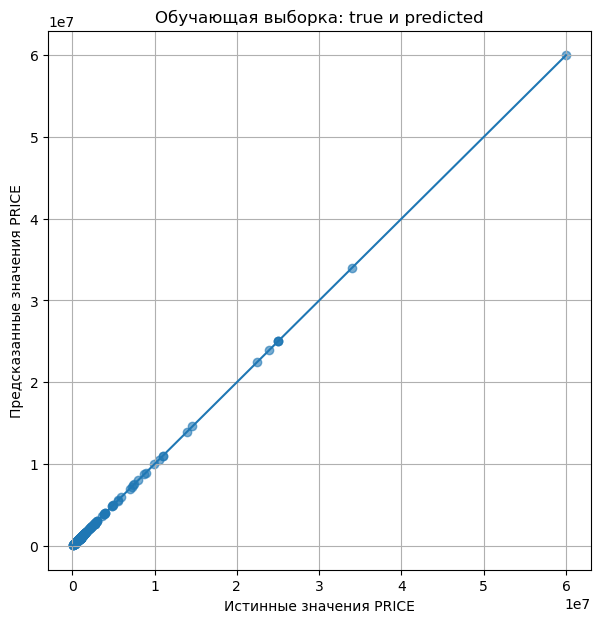

In [37]:
plt.figure(figsize=(7, 7))
plt.scatter(y_train, y_train_pred, alpha=0.6)
plt.xlabel('Истинные значения PRICE')
plt.ylabel('Предсказанные значения PRICE')
plt.title('Обучающая выборка: true и predicted')
plt.grid(True)

min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

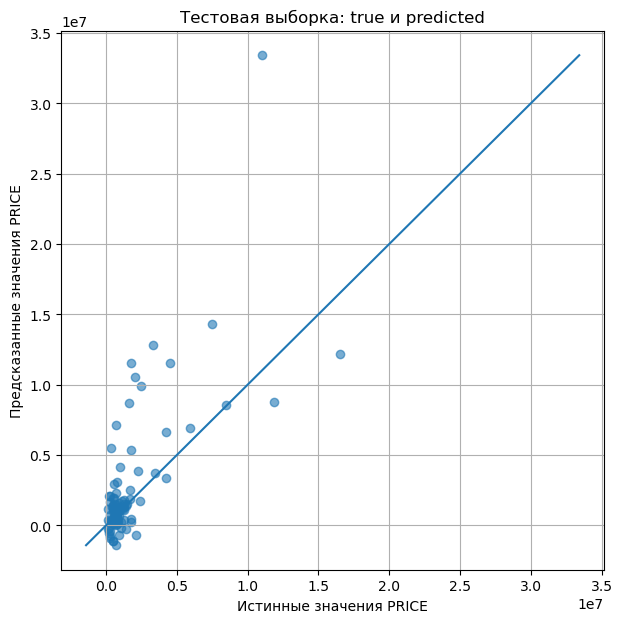

In [36]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel('Истинные значения PRICE')
plt.ylabel('Предсказанные значения PRICE')
plt.title('Тестовая выборка: true и predicted')
plt.grid(True)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

На графиках отображено соотношение между истинными значениями цены и предсказаниями модели. При хорошем качестве модели точки должны располагаться близко к биссектрисе первого координатного угла. Чем ближе облако точек к этой линии, тем точнее модель воспроизводит реальные значения целевой переменной.

Если на тестовой выборке точки заметно сильнее рассеиваются относительно биссектрисы, чем на обучающей, это указывает на ухудшение качества обобщения. Если же характер распределения точек на обучающей и тестовой выборках схож, можно сделать вывод о достаточно устойчивой работе модели.

In [38]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("MAE на обучающей выборке:", mae_train)
print("MAE на тестовой выборке:", mae_test)

MAE на обучающей выборке: 232.98632118152804
MAE на тестовой выборке: 1654012.1808842903


Метрика MAE показывает среднюю абсолютную ошибку прогноза, то есть среднее отклонение предсказанной цены от реальной в тех же единицах, что и целевой признак. Чем меньше значение MAE, тем точнее работает модель.

Сравнение значений MAE на обучающей и тестовой выборках позволяет судить о качестве обобщения. Если ошибка на тестовой выборке лишь умеренно больше, чем на обучающей, модель можно считать достаточно адекватной. Сильный рост MAE на тестовой выборке свидетельствовал бы о слабой способности модели переносить закономерности на новые данные.

In [39]:
results = pd.DataFrame({
    'True_PRICE': y_test.values,
    'Predicted_PRICE': y_test_pred
})

results['Absolute_Error'] = np.abs(results['True_PRICE'] - results['Predicted_PRICE'])

results.head(10)

,True_PRICE,Predicted_PRICE,Absolute_Error
0,319000,2.076155e+06,1.757155e+06
1,16500000,1.220238e+07,4.297620e+06
2,789000,1.271367e+06,4.823669e+05
3,749000,1.275767e+05,6.214233e+05
4,525000,1.230633e+06,7.056330e+05
5,599000,1.113944e+06,5.149437e+05
6,359000,5.504580e+06,5.145580e+06
7,799000,7.097631e+05,8.923685e+04
8,479000,1.439446e+06,9.604464e+05
9,4250000,3.381248e+06,8.687522e+05


Дополнительно были рассмотрены отдельные примеры предсказаний на тестовой выборке. Это позволяет на конкретных объектах увидеть, насколько сильно прогноз модели отличается от фактической стоимости недвижимости. Такой анализ делает оценку качества модели более наглядной и помогает лучше интерпретировать значение метрики MAE.

### Вывод

В ходе выполнения работы была построена модель линейной регрессии для прогнозирования стоимости недвижимости в Нью-Йорке. Перед обучением была реализована корректная схема предварительной обработки данных: удаление лишних признаков, обработка пропусков, масштабирование количественных признаков и кодирование категориальных признаков.

Анализ графиков true vs predicted и значений MAE на обучающей и тестовой выборках позволяет оценить предсказательную способность модели. Если точки на графиках располагаются сравнительно близко к биссектрисе, а ошибка на тестовой выборке не слишком велика относительно обучающей, можно сделать вывод, что модель улавливает основные закономерности в данных и демонстрирует удовлетворительное качество прогноза.